In [88]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadshayan5839/psx-pakistan-stock-exchange-26032026/PSX(Pakistan Stock Exchange) March(2026) .csv


# Basic  setup

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Read the dataset
df = pd.read_csv('/kaggle/input/datasets/muhammadshayan5839/psx-pakistan-stock-exchange-26032026/PSX(Pakistan Stock Exchange) March(2026) .csv')



## Display basic info

In [90]:


print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

# Convert numeric columns
numeric_columns = ['open', 'high', 'low', 'close', 'volume', 'change_pct', 
                   'market_cap_pkr_mn', 'pe_ratio', 'eps_pkr', 'shares_outstanding']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')





Dataset Shape: 300 rows, 14 columns

Columns: ['date', 'ticker', 'company_name', 'sector', 'open', 'high', 'low', 'close', 'volume', 'change_pct', 'market_cap_pkr_mn', 'pe_ratio', 'eps_pkr', 'shares_outstanding']


In [91]:
df.head()

,date,ticker,company_name,sector,open,high,low,close,volume,change_pct,market_cap_pkr_mn,pe_ratio,eps_pkr,shares_outstanding
0,2026-03-26,LUCK,Lucky Cement,Cement,813.84,821.11,762.79,770.92,11363133,-5.70,1844296.16,6.22,123.94,2392331444
1,2026-03-26,DGKC,D.G. Khan Cement,Cement,539.64,550.55,492.15,512.09,3345942,-5.64,1454966.70,28.95,17.69,2841232393
2,2026-03-26,PIOC,Pioneer Cement,Cement,510.08,527.82,504.32,509.23,2688638,-0.61,949772.52,15.59,32.66,1865115025
3,2026-03-26,KOHC,Kohat Cement,Cement,184.27,195.74,177.61,195.02,14228596,5.49,297849.87,25.34,7.70,1527278577
4,2026-03-26,MLCF,Maple Leaf Cement,Cement,945.10,1008.26,921.61,970.48,9271704,2.76,1270543.78,33.69,28.81,1309191105


##  Basic Statistics

In [92]:


print("\nNumerical Columns Summary:")
display(df[numeric_columns].describe())




Numerical Columns Summary:


,open,high,low,close,volume,change_pct,market_cap_pkr_mn,pe_ratio,eps_pkr,shares_outstanding
count,300.000000,300.000000,300.000000,300.000000,3.000000e+02,300.000000,3.000000e+02,300.000000,300.000000,3.000000e+02
mean,545.010000,563.602867,526.276500,544.960067,6.871750e+06,0.065733,7.400476e+05,21.766633,36.140567,1.321868e+09
std,307.773433,318.223047,296.548492,307.206820,3.985606e+06,3.256705,7.098132e+05,10.462554,37.617540,8.029613e+08
min,8.760000,9.070000,8.540000,8.900000,9.042300e+04,-5.910000,1.749590e+03,3.270000,0.230000,5.159503e+07
25%,265.860000,276.155000,262.517500,271.415000,3.434931e+06,-2.612500,2.024073e+05,13.217500,12.765000,5.746709e+08
50%,550.300000,562.410000,533.875000,547.580000,6.453025e+06,0.230000,5.038129e+05,21.275000,24.340000,1.347372e+09
75%,792.082500,812.690000,760.410000,791.870000,1.002439e+07,2.780000,1.034087e+06,31.175000,45.702500,1.925191e+09
max,1252.070000,1269.380000,1174.620000,1198.160000,1.499250e+07,5.950000,3.307666e+06,39.980000,206.130000,2.906617e+09


In [93]:
print("\nData Types:")
print(df.dtypes)




Data Types:
date                   object
ticker                 object
company_name           object
sector                 object
open                  float64
high                  float64
low                   float64
close                 float64
volume                  int64
change_pct            float64
market_cap_pkr_mn     float64
pe_ratio              float64
eps_pkr               float64
shares_outstanding      int64
dtype: object


In [94]:
print("\nMissing Values:")
print(df.isnull().sum())




Missing Values:
date                  0
ticker                0
company_name          0
sector                0
open                  0
high                  0
low                   0
close                 0
volume                0
change_pct            0
market_cap_pkr_mn     0
pe_ratio              0
eps_pkr               0
shares_outstanding    0
dtype: int64


In [95]:
print("\nSector Distribution:")
sector_counts = df['sector'].value_counts()
print(sector_counts)


Sector Distribution:
sector
Oil & Gas        26
Pharma           26
Textile          24
Auto             21
Technology       21
Cement           20
Food & FMCG      20
Power            18
Banking          18
Real Estate      15
Insurance        15
Fertilizer       14
Steel            14
Miscellaneous    14
Leasing          14
Chemical         13
Telecom           7
Name: count, dtype: int64


#  Sector Distribution Visualization

## Pie chart
## Bar plot
## Interactive version with plotly

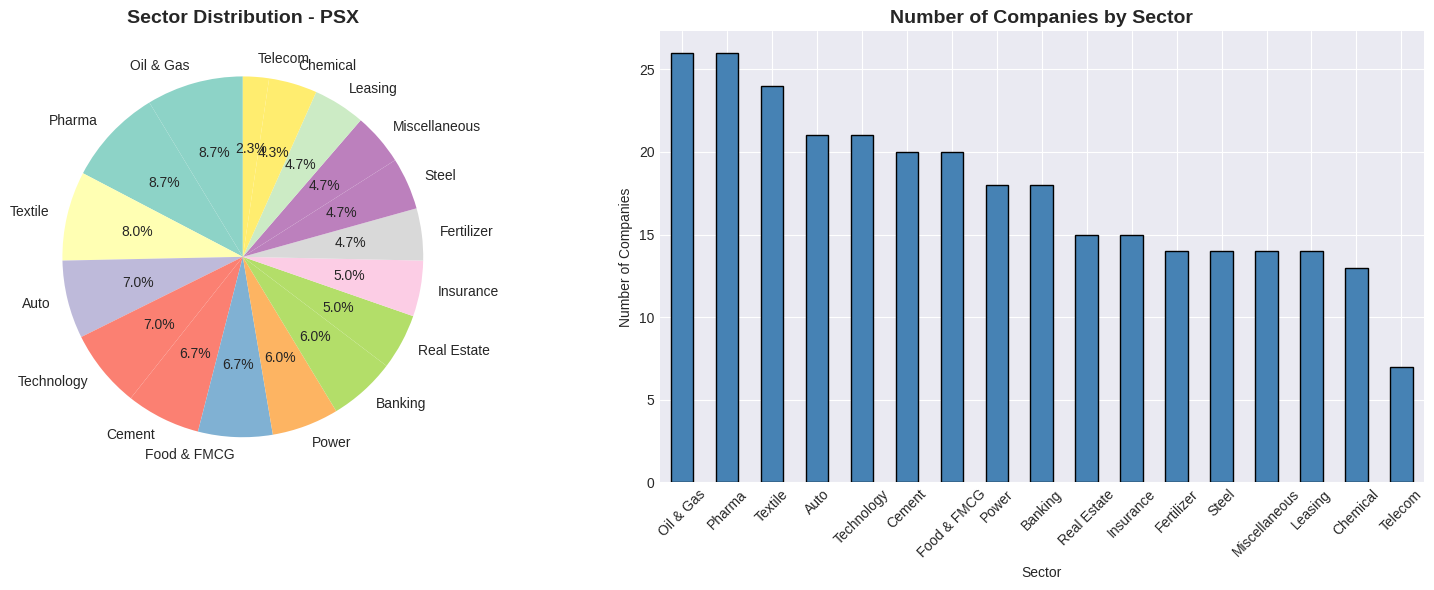

In [96]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(sector_counts)))
wedges, texts, autotexts = axes[0].pie(sector_counts.values, 
                                         labels=sector_counts.index, 
                                         autopct='%1.1f%%',
                                         colors=colors,
                                         startangle=90)
axes[0].set_title('Sector Distribution - PSX', fontsize=14, fontweight='bold')

# Bar plot
sector_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Number of Companies by Sector', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sector')
axes[1].set_ylabel('Number of Companies')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Interactive version with plotly
fig = px.pie(df, names='sector', title='Sector Distribution - Interactive', 
             hole=0.3, color_discrete_sequence=px.colors.qualitative.Set3)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

#  Price Analysis - Distribution of Close Prices

## Histogram
## Box plot by sector
## QQ plot for normality check
## Top 10 highest close prices

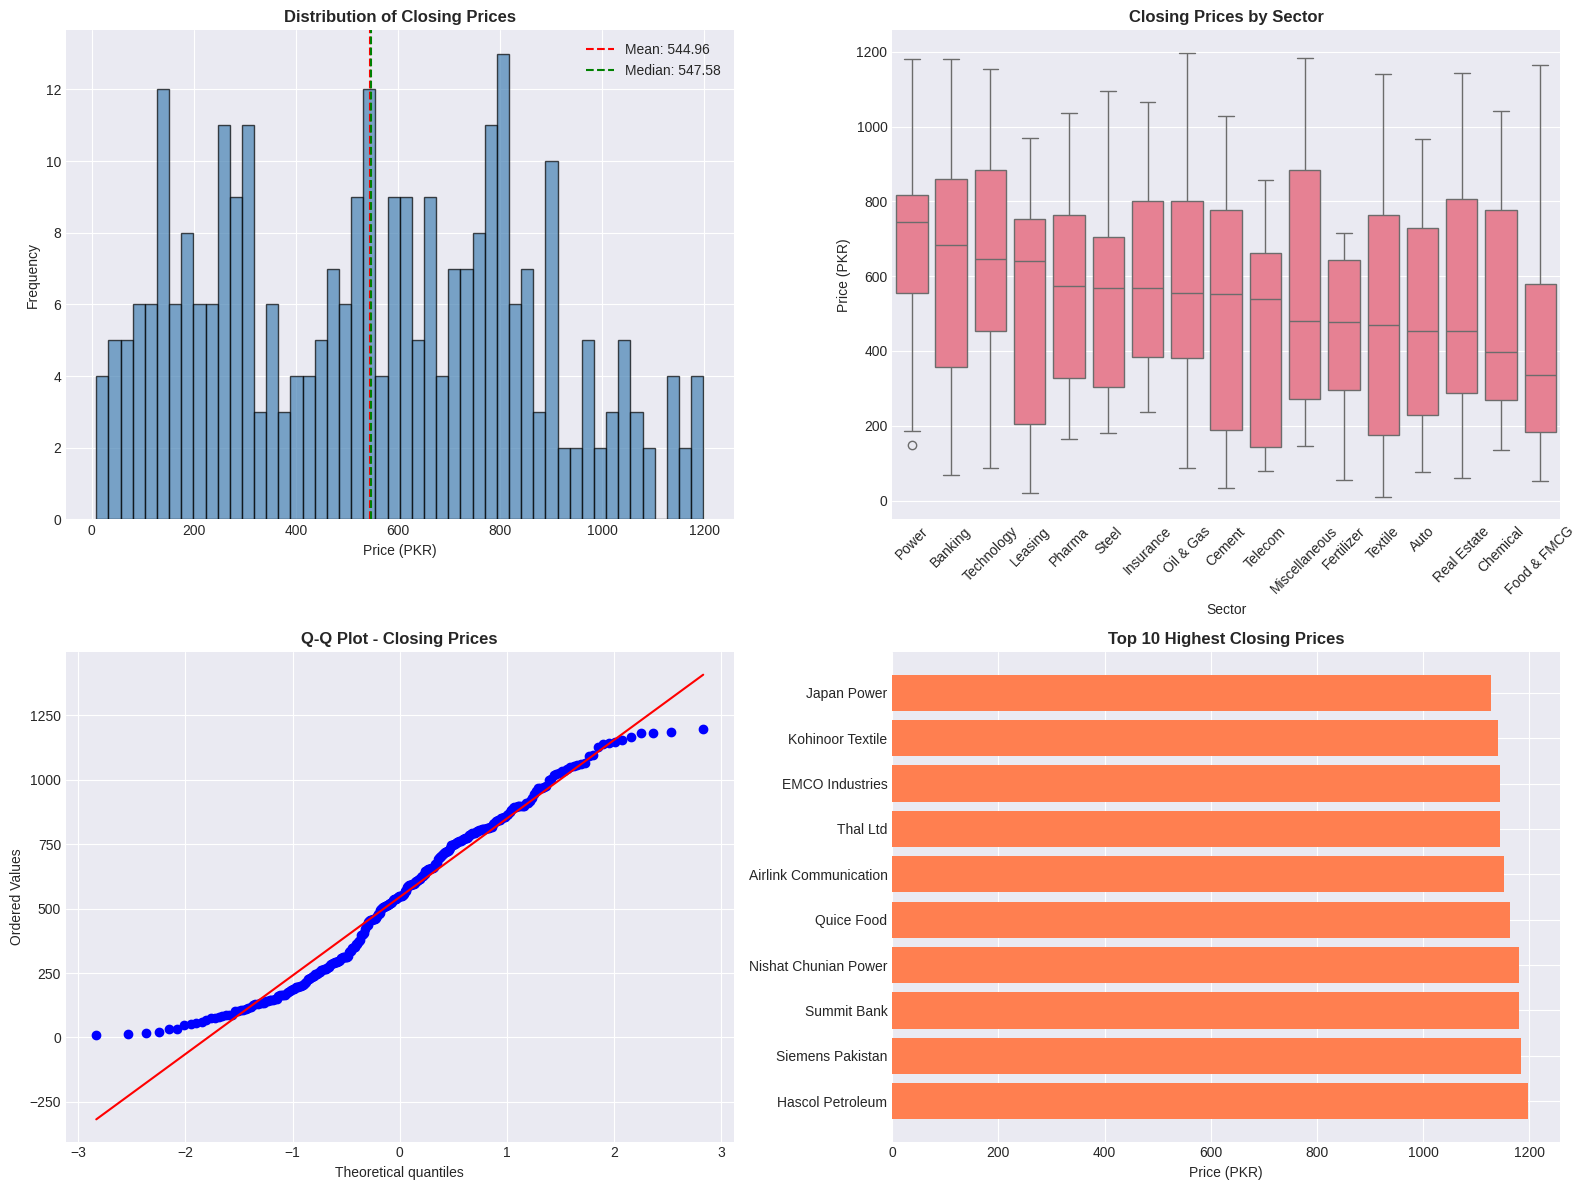

In [97]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
axes[0, 0].hist(df['close'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribution of Closing Prices', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price (PKR)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['close'].mean(), color='red', linestyle='--', label=f'Mean: {df["close"].mean():.2f}')
axes[0, 0].axvline(df['close'].median(), color='green', linestyle='--', label=f'Median: {df["close"].median():.2f}')
axes[0, 0].legend()

# Box plot by sector
sector_order = df.groupby('sector')['close'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='sector', y='close', order=sector_order, ax=axes[0, 1])
axes[0, 1].set_title('Closing Prices by Sector', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Sector')
axes[0, 1].set_ylabel('Price (PKR)')
axes[0, 1].tick_params(axis='x', rotation=45)

# QQ plot for normality check
from scipy import stats
stats.probplot(df['close'].dropna(), dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot - Closing Prices', fontsize=12, fontweight='bold')

# Top 10 highest close prices
top10 = df.nlargest(10, 'close')[['company_name', 'sector', 'close']]
axes[1, 1].barh(range(len(top10)), top10['close'].values, color='coral')
axes[1, 1].set_yticks(range(len(top10)))
axes[1, 1].set_yticklabels(top10['company_name'].values)
axes[1, 1].set_title('Top 10 Highest Closing Prices', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Price (PKR)')

plt.tight_layout()
plt.show()

#  Market Capitalization Analysis

## Market cap by sector (box plot)
## Top 10 by market cap
## Market cap distribution

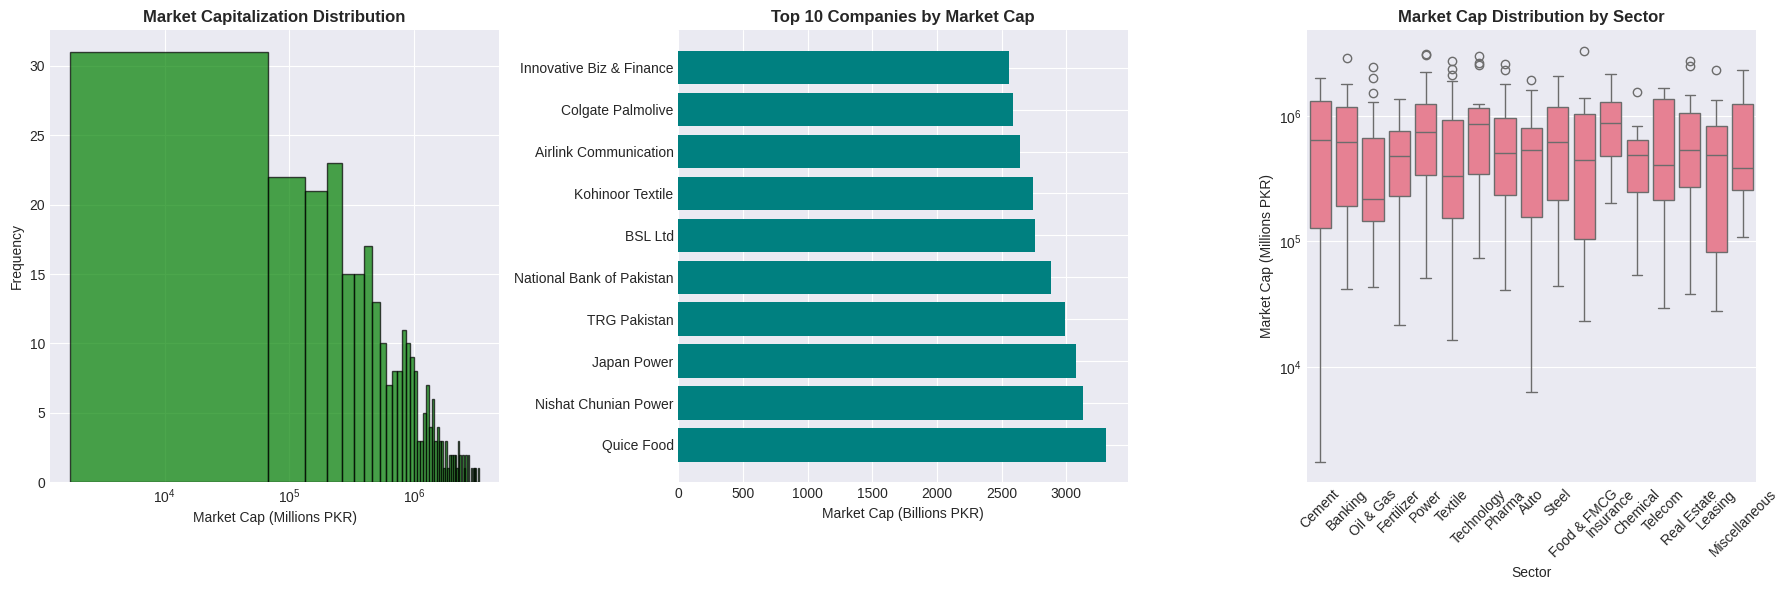

In [98]:
#  Market Capitalization Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Market cap distribution
axes[0].hist(df['market_cap_pkr_mn'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].set_title('Market Capitalization Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Market Cap (Millions PKR)')
axes[0].set_ylabel('Frequency')
axes[0].set_xscale('log')

# Top 10 by market cap
top10_mcap = df.nlargest(10, 'market_cap_pkr_mn')[['company_name', 'sector', 'market_cap_pkr_mn']]
axes[1].barh(range(len(top10_mcap)), top10_mcap['market_cap_pkr_mn'].values/1000, color='teal')
axes[1].set_yticks(range(len(top10_mcap)))
axes[1].set_yticklabels(top10_mcap['company_name'].values)
axes[1].set_title('Top 10 Companies by Market Cap', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Market Cap (Billions PKR)')

# Market cap by sector (box plot)
sns.boxplot(data=df, x='sector', y='market_cap_pkr_mn', ax=axes[2])
axes[2].set_title('Market Cap Distribution by Sector', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Sector')
axes[2].set_ylabel('Market Cap (Millions PKR)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

#  Volume Analysis

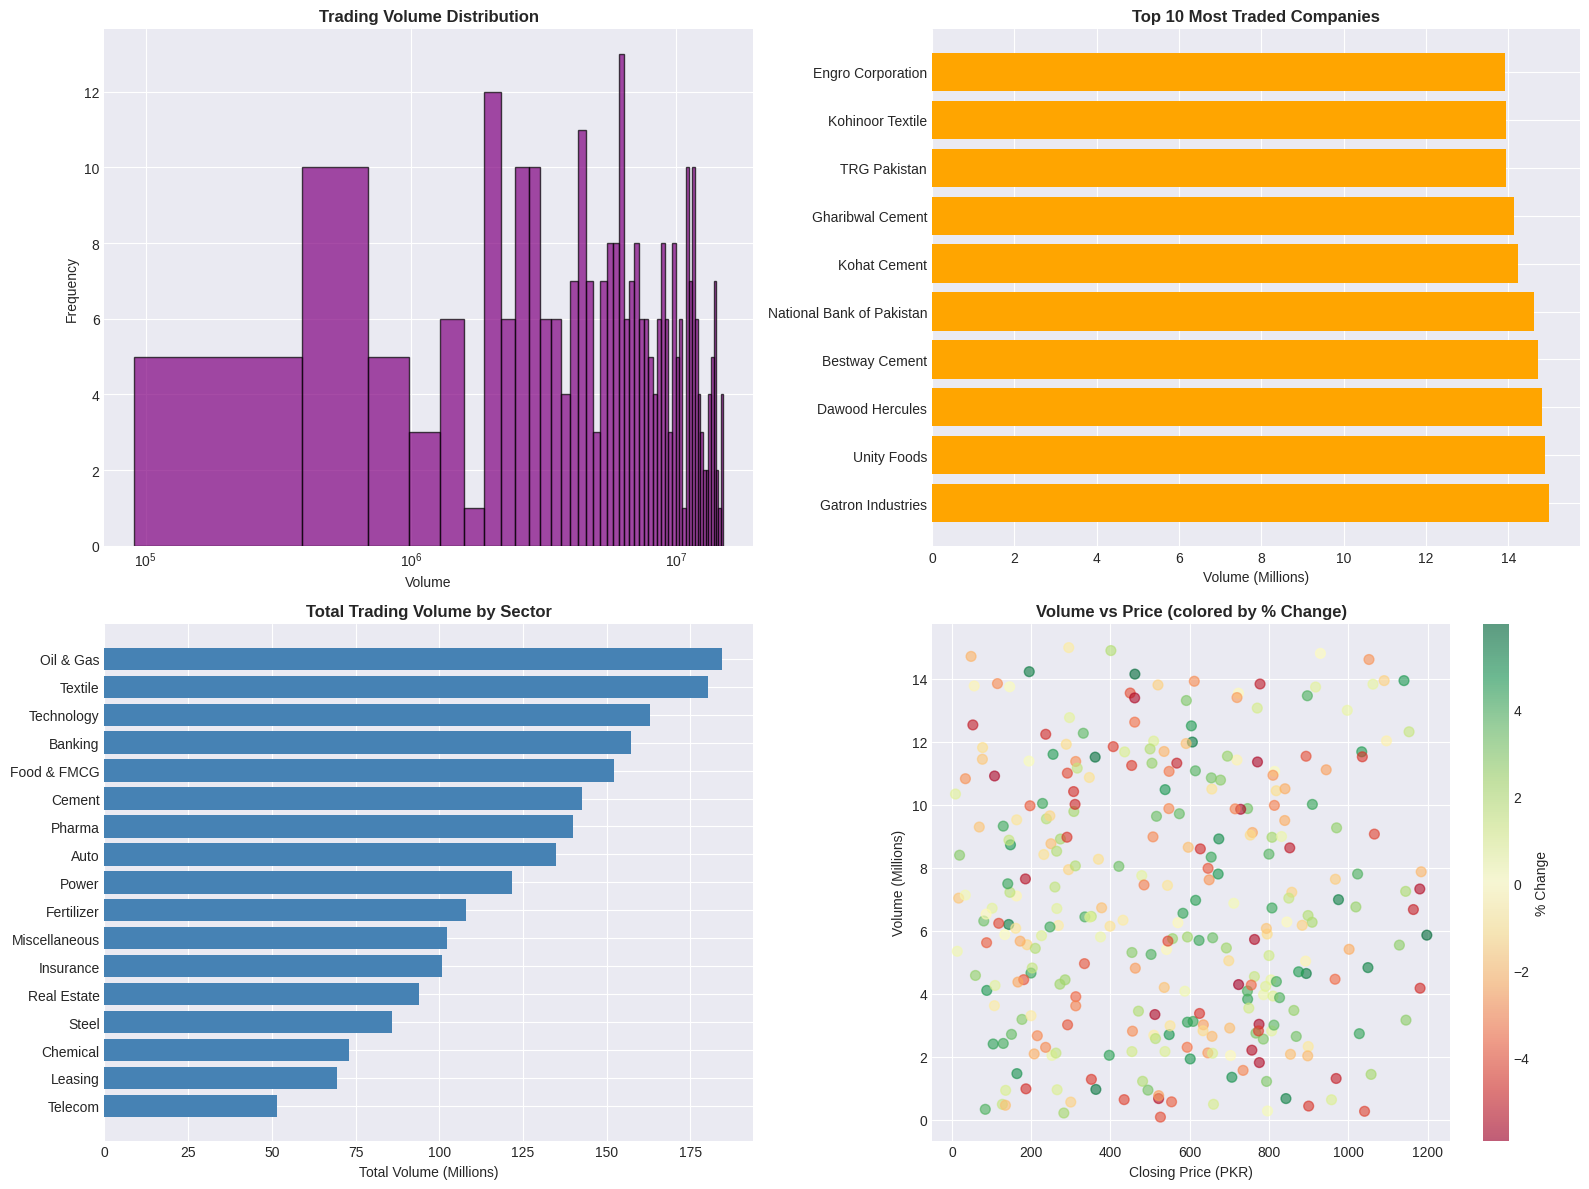

In [99]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Volume distribution
axes[0, 0].hist(df['volume'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0, 0].set_title('Trading Volume Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Volume')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_xscale('log')

# Top 10 by volume
top10_vol = df.nlargest(10, 'volume')[['company_name', 'sector', 'volume']]
axes[0, 1].barh(range(len(top10_vol)), top10_vol['volume'].values/1e6, color='orange')
axes[0, 1].set_yticks(range(len(top10_vol)))
axes[0, 1].set_yticklabels(top10_vol['company_name'].values)
axes[0, 1].set_title('Top 10 Most Traded Companies', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Volume (Millions)')

# Volume by sector
sector_volume = df.groupby('sector')['volume'].sum().sort_values(ascending=True)
axes[1, 0].barh(sector_volume.index, sector_volume.values/1e6, color='steelblue')
axes[1, 0].set_title('Total Trading Volume by Sector', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Total Volume (Millions)')

# Volume vs Price scatter
scatter = axes[1, 1].scatter(df['close'], df['volume']/1e6, c=df['change_pct'], 
                              cmap='RdYlGn', alpha=0.6, s=50)
axes[1, 1].set_xlabel('Closing Price (PKR)')
axes[1, 1].set_ylabel('Volume (Millions)')
axes[1, 1].set_title('Volume vs Price (colored by % Change)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 1], label='% Change')

plt.tight_layout()
plt.show()

#  Price Change Analysis

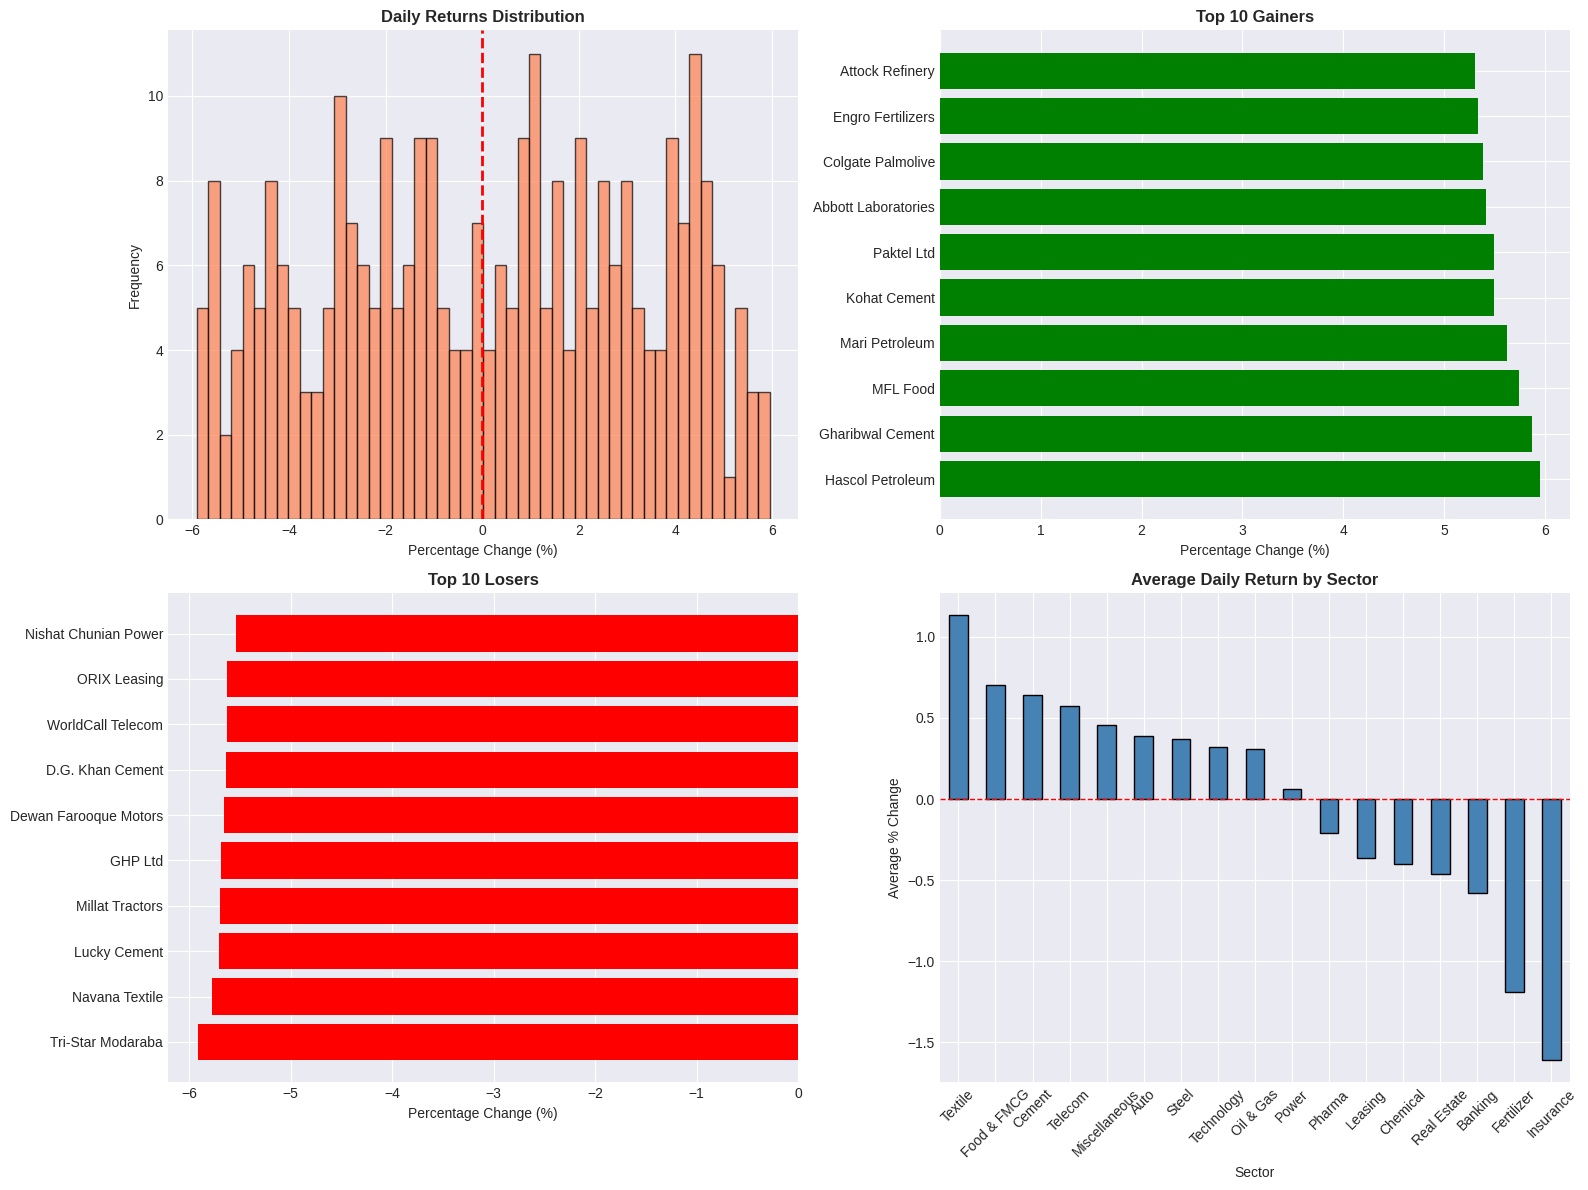

RETURNS ANALYSIS
Average Daily Return: 0.07%
Median Daily Return: 0.23%
Number of Gainers: 154
Number of Losers: 146
Number of Unchanged: 0


In [100]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Change percentage distribution
axes[0, 0].hist(df['change_pct'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 0].set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Percentage Change (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)

# Top gainers and losers
gainers = df.nlargest(10, 'change_pct')[['company_name', 'sector', 'change_pct', 'close']]
losers = df.nsmallest(10, 'change_pct')[['company_name', 'sector', 'change_pct', 'close']]

# Gainers
colors_gain = ['green' if x > 0 else 'red' for x in gainers['change_pct']]
axes[0, 1].barh(range(len(gainers)), gainers['change_pct'].values, color=colors_gain)
axes[0, 1].set_yticks(range(len(gainers)))
axes[0, 1].set_yticklabels(gainers['company_name'].values)
axes[0, 1].set_title('Top 10 Gainers', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Percentage Change (%)')

# Losers
colors_loss = ['green' if x > 0 else 'red' for x in losers['change_pct']]
axes[1, 0].barh(range(len(losers)), losers['change_pct'].values, color=colors_loss)
axes[1, 0].set_yticks(range(len(losers)))
axes[1, 0].set_yticklabels(losers['company_name'].values)
axes[1, 0].set_title('Top 10 Losers', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Percentage Change (%)')

# Change by sector
sector_change = df.groupby('sector')['change_pct'].agg(['mean', 'std']).sort_values('mean', ascending=False)
sector_change['mean'].plot(kind='bar', ax=axes[1, 1], color='steelblue', edgecolor='black')
axes[1, 1].set_title('Average Daily Return by Sector', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sector')
axes[1, 1].set_ylabel('Average % Change')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

# Summary statistics

print("RETURNS ANALYSIS")

print(f"Average Daily Return: {df['change_pct'].mean():.2f}%")
print(f"Median Daily Return: {df['change_pct'].median():.2f}%")
print(f"Number of Gainers: {(df['change_pct'] > 0).sum()}")
print(f"Number of Losers: {(df['change_pct'] < 0).sum()}")
print(f"Number of Unchanged: {(df['change_pct'] == 0).sum()}")

#  Valuation Metrics Analysis

## P/E Ratio distribution
## EPS Distribution
## P/E Ratio by sector (top sectors)
## Price vs EPS scatter

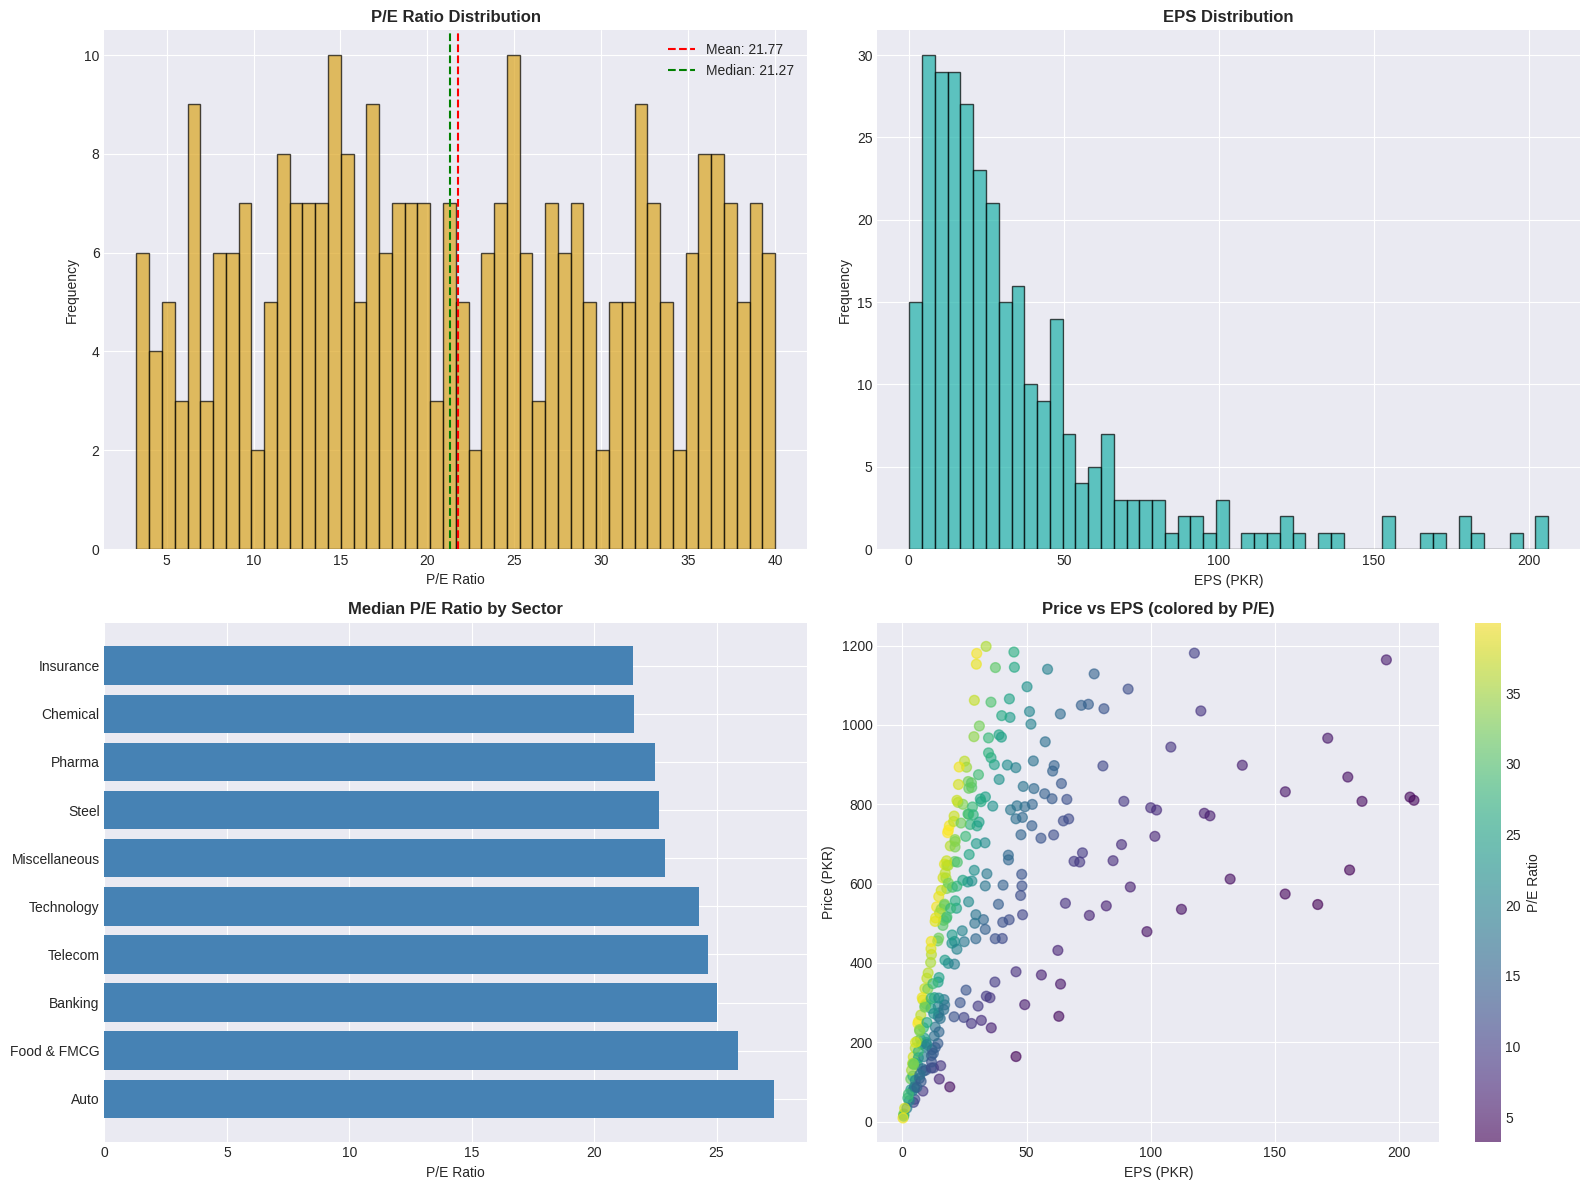

In [101]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# P/E Ratio distribution
axes[0, 0].hist(df['pe_ratio'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='goldenrod')
axes[0, 0].set_title('P/E Ratio Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('P/E Ratio')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['pe_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {df["pe_ratio"].mean():.2f}')
axes[0, 0].axvline(df['pe_ratio'].median(), color='green', linestyle='--', label=f'Median: {df["pe_ratio"].median():.2f}')
axes[0, 0].legend()

# EPS Distribution
axes[0, 1].hist(df['eps_pkr'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='lightseagreen')
axes[0, 1].set_title('EPS Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('EPS (PKR)')
axes[0, 1].set_ylabel('Frequency')

# P/E Ratio by sector (top sectors)
sector_pe = df.groupby('sector')['pe_ratio'].median().sort_values(ascending=False).head(10)
axes[1, 0].barh(sector_pe.index, sector_pe.values, color='steelblue')
axes[1, 0].set_title('Median P/E Ratio by Sector', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('P/E Ratio')

# Price vs EPS scatter
axes[1, 1].scatter(df['eps_pkr'], df['close'], c=df['pe_ratio'], cmap='viridis', alpha=0.6, s=50)
axes[1, 1].set_xlabel('EPS (PKR)')
axes[1, 1].set_ylabel('Price (PKR)')
axes[1, 1].set_title('Price vs EPS (colored by P/E)', fontsize=12, fontweight='bold')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='P/E Ratio')

plt.tight_layout()
plt.show()

#  Correlation Analysis and Heatmap

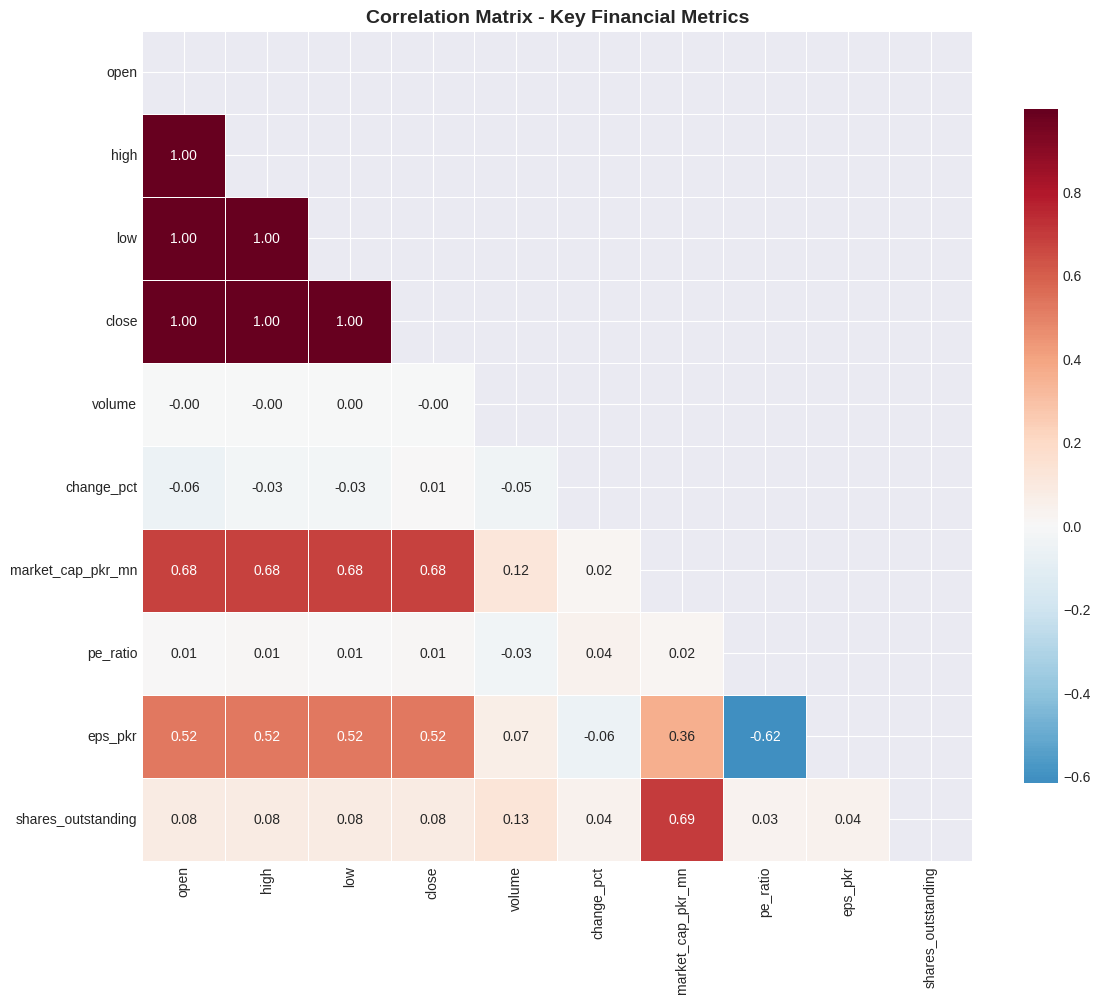

Open vs Close: 0.997
High vs Low: 0.999
Market Cap vs Price: 0.680
EPS vs Price: 0.521
Volume vs Change %: -0.048


In [102]:

# Select numeric columns for correlation
corr_columns = ['open', 'high', 'low', 'close', 'volume', 'change_pct', 'market_cap_pkr_mn', 
                'pe_ratio', 'eps_pkr', 'shares_outstanding']

corr_matrix = df[corr_columns].corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Key Financial Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Key correlations

print(f"Open vs Close: {corr_matrix.loc['open', 'close']:.3f}")
print(f"High vs Low: {corr_matrix.loc['high', 'low']:.3f}")
print(f"Market Cap vs Price: {corr_matrix.loc['market_cap_pkr_mn', 'close']:.3f}")
print(f"EPS vs Price: {corr_matrix.loc['eps_pkr', 'close']:.3f}")
print(f"Volume vs Change %: {corr_matrix.loc['volume', 'change_pct']:.3f}")

#  Sector-wise Performance Dashboard

In [103]:


fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Average Price by Sector', 'Average P/E Ratio by Sector',
                    'Average EPS by Sector', 'Average Return by Sector'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

# Sector aggregations
sector_avg_price = df.groupby('sector')['close'].mean().sort_values(ascending=False)
sector_avg_pe = df.groupby('sector')['pe_ratio'].mean().sort_values(ascending=False)
sector_avg_eps = df.groupby('sector')['eps_pkr'].mean().sort_values(ascending=False)
sector_avg_return = df.groupby('sector')['change_pct'].mean().sort_values(ascending=False)

# Add traces
fig.add_trace(go.Bar(x=sector_avg_price.index, y=sector_avg_price.values, name='Avg Price'), row=1, col=1)
fig.add_trace(go.Bar(x=sector_avg_pe.index, y=sector_avg_pe.values, name='Avg P/E', marker_color='orange'), row=1, col=2)
fig.add_trace(go.Bar(x=sector_avg_eps.index, y=sector_avg_eps.values, name='Avg EPS', marker_color='green'), row=2, col=1)
fig.add_trace(go.Bar(x=sector_avg_return.index, y=sector_avg_return.values, name='Avg Return', marker_color='red'), row=2, col=2)

# Update layout
fig.update_layout(height=800, width=1200, title_text="Sector-wise Performance Dashboard", showlegend=False)
fig.update_xaxes(tickangle=45)

fig.show()

# Visualizations - Interactive with Plotly

##  Scatter plot matrix for key metrics
## 3D Scatter plot with fixed size parameter
## Alternative 3D scatter plot using volume directly
## Sunburst chart for hierarchical view

In [104]:

# Create a copy for visualization with absolute values for size
df_viz = df.copy()
# For size parameter, we need non-negative values - use absolute volume or create a scaled version
df_viz['size_for_3d'] = df_viz['volume'] / df_viz['volume'].max() * 100  # Scale volume to 0-100 range
df_viz['abs_change'] = df_viz['change_pct'].abs()  # For color intensity

# Scatter plot matrix for key metrics
fig = px.scatter_matrix(df_viz,
                        dimensions=['close', 'volume', 'market_cap_pkr_mn', 'pe_ratio', 'eps_pkr'],
                        color='sector',
                        title='Scatter Matrix - Key Financial Metrics',
                        height=800,
                        opacity=0.7)
fig.show()

# 3D Scatter plot with fixed size parameter
fig = px.scatter_3d(df_viz, 
                    x='close', 
                    y='volume', 
                    z='market_cap_pkr_mn',
                    color='change_pct',  # Use change_pct for color to show performance
                    size='size_for_3d',  # Use scaled volume for size (non-negative)
                    hover_name='company_name',
                    title='3D Visualization: Price vs Volume vs Market Cap (Colored by % Change)',
                    labels={
                        'close': 'Price (PKR)', 
                        'volume': 'Volume', 
                        'market_cap_pkr_mn': 'Market Cap (M PKR)',
                        'change_pct': 'Daily Change (%)'
                    },
                    color_continuous_scale='RdYlGn',  # Red-Yellow-Green for negative-positive
                    size_max=15)  # Limit maximum marker size
fig.show()

# Alternative 3D scatter plot using volume directly (without scaling)
fig2 = px.scatter_3d(df_viz, 
                     x='close', 
                     y='volume', 
                     z='market_cap_pkr_mn',
                     color='sector',
                     size='size_for_3d',
                     hover_name='company_name',
                     title='3D Visualization: Price vs Volume vs Market Cap (Colored by Sector)',
                     labels={
                         'close': 'Price (PKR)', 
                         'volume': 'Volume', 
                         'market_cap_pkr_mn': 'Market Cap (M PKR)'
                     },
                     size_max=15)
fig2.show()

# Sunburst chart for hierarchical view
fig = px.sunburst(df_viz, 
                  path=['sector', 'company_name'], 
                  values='market_cap_pkr_mn',
                  title='Market Cap Distribution by Sector and Company',
                  color='market_cap_pkr_mn', 
                  color_continuous_scale='Viridis',
                  hover_data=['close', 'change_pct'])
fig.update_layout(width=1000, height=800)
fig.show()

#  Statistical Summary Report

In [105]:


# Sector performance table
sector_performance = df.groupby('sector').agg({
    'close': ['mean', 'median', 'std'],
    'change_pct': ['mean', 'std'],
    'market_cap_pkr_mn': ['sum', 'mean'],
    'volume': 'sum',
    'pe_ratio': 'mean'
}).round(2)

sector_performance.columns = ['Avg Price', 'Median Price', 'Price Std', 
                               'Avg Return %', 'Return Std', 
                               'Total Market Cap (M)', 'Avg Market Cap (M)',
                               'Total Volume', 'Avg P/E']

sector_performance = sector_performance.sort_values('Total Market Cap (M)', ascending=False)
display(sector_performance)

# Top performers by different metrics

print("TOP PERFORMERS")

print("\nHighest Market Cap:")
display(df.nlargest(5, 'market_cap_pkr_mn')[['company_name', 'sector', 'market_cap_pkr_mn', 'close']])

print("\nHighest Price:")
display(df.nlargest(5, 'close')[['company_name', 'sector', 'close', 'change_pct']])

print("\nHighest Trading Volume:")
display(df.nlargest(5, 'volume')[['company_name', 'sector', 'volume', 'close', 'change_pct']])

print("\nHighest Return:")
display(df.nlargest(5, 'change_pct')[['company_name', 'sector', 'change_pct', 'close']])

print("\nMost Expensive (P/E Ratio):")
display(df.nlargest(5, 'pe_ratio')[['company_name', 'sector', 'pe_ratio', 'eps_pkr', 'close']])

,Avg Price,Median Price,Price Std,Avg Return %,Return Std,Total Market Cap (M),Avg Market Cap (M),Total Volume,Avg P/E
sector,,,,,,,,,
Technology,639.76,646.20,312.29,0.32,3.22,19930628.90,949077.57,162874364,22.25
Pharma,566.35,573.68,257.88,-0.21,3.24,19306871.19,742571.97,139946297,23.14
Power,681.86,745.24,314.76,0.06,3.42,18984781.42,1054710.08,121898717,22.66
Textile,473.89,470.00,348.47,1.13,2.94,17255537.46,718980.73,180327084,17.98
Cement,533.20,552.80,319.18,0.64,3.77,15276015.06,763800.75,142771834,20.42
Banking,624.19,684.05,326.28,-0.58,3.03,14643620.27,813534.46,157168561,22.22
Insurance,621.63,567.31,275.38,-1.61,2.93,14191554.71,946103.65,100844531,21.66
Oil & Gas,560.72,554.47,291.93,0.31,3.10,13950182.24,536545.47,184411535,20.64
Food & FMCG,421.57,336.78,310.59,0.70,3.30,13838348.49,691917.42,152180899,23.70


TOP PERFORMERS

Highest Market Cap:


,company_name,sector,market_cap_pkr_mn,close
115,Quice Food,Food & FMCG,3307665.90,1164.25
49,Nishat Chunian Power,Power,3132444.75,1180.43
51,Japan Power,Power,3077896.47,1128.91
75,TRG Pakistan,Technology,2992453.47,1090.55
15,National Bank of Pakistan,Banking,2878608.64,1052.26



Highest Price:


,company_name,sector,close,change_pct
35,Hascol Petroleum,Oil & Gas,1198.16,5.95
170,Siemens Pakistan,Miscellaneous,1183.97,-2.12
25,Summit Bank,Banking,1181.16,-4.82
49,Nishat Chunian Power,Power,1180.43,-5.54
115,Quice Food,Food & FMCG,1164.25,-5.10


...

,company_name,sector,volume,close,change_pct
63,Gatron Industries,Textile,14992504,294.70,-0.72
116,Unity Foods,Food & FMCG,14898750,400.99,2.09
169,Dawood Hercules,Miscellaneous,14808312,929.69,-0.07
9,Bestway Cement,Cement,14713008,48.20,-2.21
15,National Bank of Pakistan,Banking,14614878,1052.26,-2.84



Highest Return:


,company_name,sector,change_pct,close
35,Hascol Petroleum,Oil & Gas,5.95,1198.16
8,Gharibwal Cement,Cement,5.87,461.55
124,MFL Food,Food & FMCG,5.74,361.32
30,Mari Petroleum,Oil & Gas,5.62,363.08
3,Kohat Cement,Cement,5.49,195.02



Most Expensive (P/E Ratio):


,company_name,sector,pe_ratio,eps_pkr,close
99,Millat Tractors,Auto,39.98,18.22,728.42
123,PM Pakistan,Food & FMCG,39.73,6.22,247.07
106,Mughal Steel,Steel,39.71,18.50,734.56
5,Fauji Cement,Cement,39.45,18.91,746.04
49,Nishat Chunian Power,Power,39.42,29.94,1180.43


# Prepare data for potential ML pipeline

In [106]:


print("DATA PREPARATION FOR ML PIPELINE")


# Check for missing values
print("\nMissing Values Summary:")
print(df.isnull().sum())

# Create derived features for ML
df_ml = df.copy()

# Add price range feature
df_ml['price_range'] = df_ml['high'] - df_ml['low']
df_ml['price_range_pct'] = (df_ml['price_range'] / df_ml['open']) * 100

# Add volume category
df_ml['volume_category'] = pd.qcut(df_ml['volume'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

# Add market cap category
df_ml['mcap_category'] = pd.qcut(df_ml['market_cap_pkr_mn'], q=4, labels=['Small', 'Medium', 'Large', 'Mega'])

# Create target variable for classification (if we want to predict if stock will be gainer)
df_ml['is_gainer'] = (df_ml['change_pct'] > 0).astype(int)

# Create target for regression (predict next day price - for demonstration)
# Note: This is synthetic since we only have one day of data

print("\nPrepared Dataset Shape:", df_ml.shape)
print("\nNew Features Created:")
print("- price_range: Intraday price movement")
print("- price_range_pct: Percentage price movement")
print("- volume_category: Quartile-based volume category")
print("- mcap_category: Quartile-based market cap category")
print("- is_gainer: Binary target for classification")

print("\nSample of prepared data:")
display(df_ml[['ticker', 'close', 'change_pct', 'price_range', 'price_range_pct', 
               'volume_category', 'mcap_category', 'is_gainer']].head(10))

# Save prepared dataset
# df_ml.to_csv('psx_prepared_for_ml.csv', index=False)
# print("\nFAHH")

DATA PREPARATION FOR ML PIPELINE

Missing Values Summary:
date                  0
ticker                0
company_name          0
sector                0
open                  0
high                  0
low                   0
close                 0
volume                0
change_pct            0
market_cap_pkr_mn     0
pe_ratio              0
eps_pkr               0
shares_outstanding    0
dtype: int64

Prepared Dataset Shape: (300, 19)

New Features Created:
- price_range: Intraday price movement
- price_range_pct: Percentage price movement
- volume_category: Quartile-based volume category
- mcap_category: Quartile-based market cap category
- is_gainer: Binary target for classification

Sample of prepared data:


,ticker,close,change_pct,price_range,price_range_pct,volume_category,mcap_category,is_gainer
0,LUCK,770.92,-5.70,58.32,7.166028,High,Mega,0
1,DGKC,512.09,-5.64,58.40,10.822030,Low,Mega,0
2,PIOC,509.23,-0.61,23.50,4.607120,Low,Large,0
3,KOHC,195.02,5.49,18.13,9.838823,High,Medium,1
4,MLCF,970.48,2.76,86.65,9.168342,Medium-High,Mega,1
5,FCCL,746.04,4.34,78.29,10.932678,Medium-Low,Large,1
6,CHCC,1027.83,4.40,70.84,7.212748,Low,Mega,1
7,ACPL,807.51,2.42,30.05,3.797452,Medium-High,Large,1
8,GWLC,461.55,5.87,40.17,9.188435,High,Small,1
9,BWCL,48.20,-2.21,1.38,2.812882,High,Small,0


#  Machine Learning Pipeline 

Training set size: 240
Test set size: 60

Target distribution:
Gainers: 154 (51.3%)
Losers: 146 (48.7%)
RANDOM FOREST CLASSIFIER RESULTS
Accuracy: 0.3833

Classification Report:
              precision    recall  f1-score   support

      Losers       0.36      0.34      0.35        29
     Gainers       0.41      0.42      0.41        31

    accuracy                           0.38        60
   macro avg       0.38      0.38      0.38        60
weighted avg       0.38      0.38      0.38        60


Feature Importance:
              feature  importance
7  shares_outstanding    0.141567
4            pe_ratio    0.119251
3              volume    0.116367
9     price_range_pct    0.114789
8         price_range    0.093901
5             eps_pkr    0.088583
0                open    0.086637
6   market_cap_pkr_mn    0.084801
1                high    0.078366
2                 low    0.075737


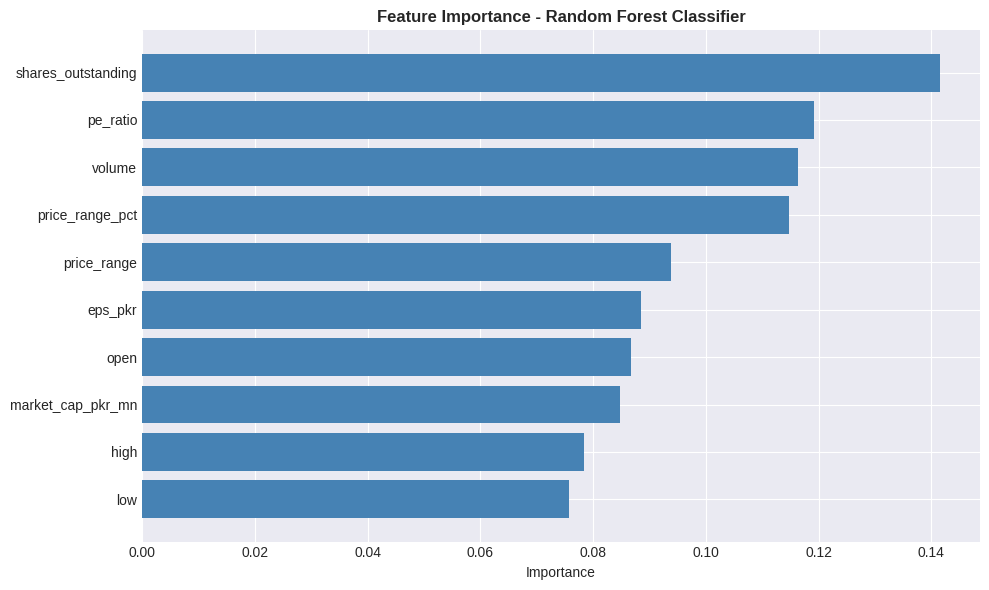

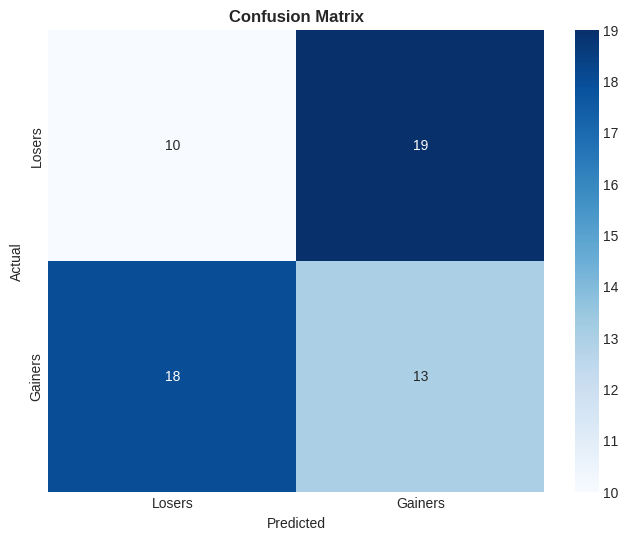

In [107]:




# Prepare features for ML
# Let's create a classification model to predict if a stock will be a gainer

# Select features
feature_cols = ['open', 'high', 'low', 'volume', 'pe_ratio', 'eps_pkr', 
                'market_cap_pkr_mn', 'shares_outstanding', 'price_range', 'price_range_pct']

# Handle missing values
df_ml_clean = df_ml[feature_cols + ['is_gainer']].dropna()

X = df_ml_clean[feature_cols]
y = df_ml_clean['is_gainer']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTarget distribution:")
print(f"Gainers: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Losers: {(~y.astype(bool)).sum()} ({(1-y.mean())*100:.1f}%)")

# Create pipeline
numeric_features = feature_cols

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Random Forest Classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train model
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred = rf_pipeline.predict(X_test)
y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluate

print("RANDOM FOREST CLASSIFIER RESULTS")

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Losers', 'Gainers']))

# Feature importance
rf_model = rf_pipeline.named_steps['classifier']
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest Classifier', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Losers', 'Gainers'], 
            yticklabels=['Losers', 'Gainers'])
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#  Regression Model for Price Prediction

REGRESSION MODEL - PRICE PREDICTION
Training set size: 240
Test set size: 60

Price Statistics:
Mean Price: 544.96
Std Price: 307.21
RANDOM FOREST REGRESSOR RESULTS
R² Score: 0.9978
RMSE: 14.40 PKR
MAPE: 2.61%


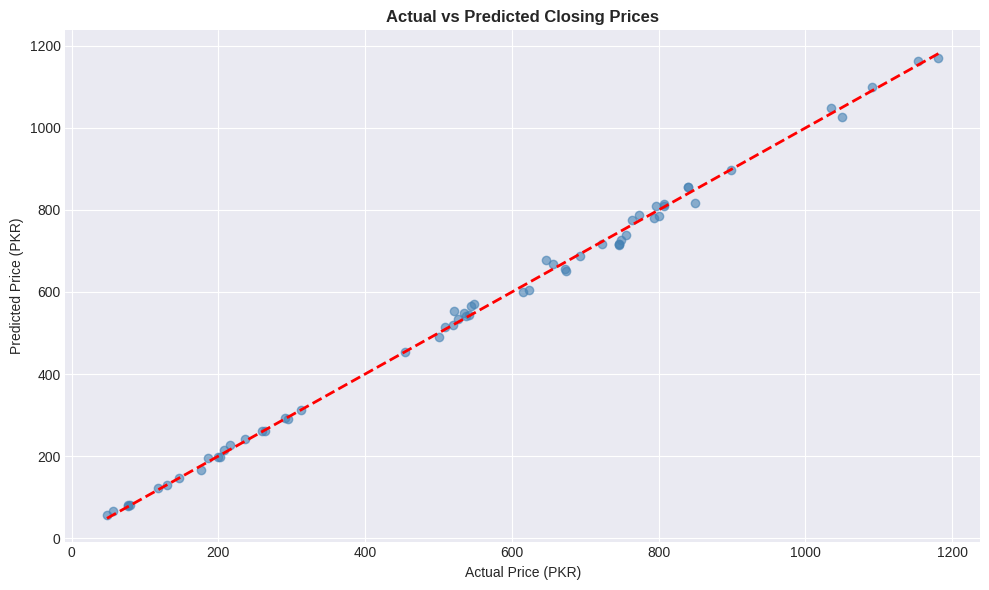


Feature Importance - Regression:
              feature  importance
1                high    0.534269
2                 low    0.372385
0                open    0.092144
5             eps_pkr    0.000377
8         price_range    0.000184
3              volume    0.000168
4            pe_ratio    0.000120
7  shares_outstanding    0.000120
6   market_cap_pkr_mn    0.000119
9     price_range_pct    0.000113


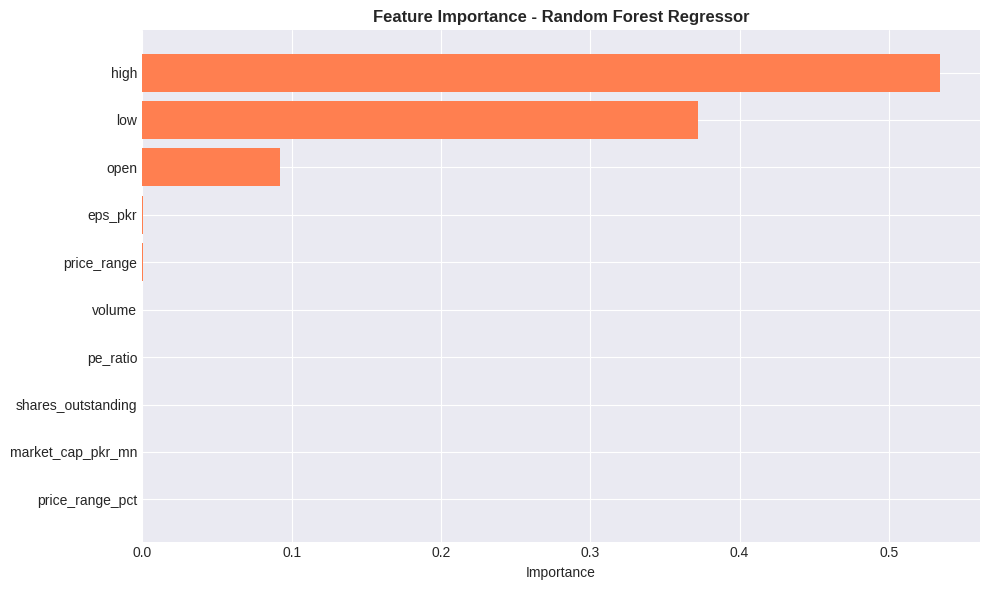

In [108]:

print("REGRESSION MODEL - PRICE PREDICTION")


# Prepare data for regression (predict closing price)
reg_feature_cols = ['open', 'high', 'low', 'volume', 'pe_ratio', 'eps_pkr', 
                    'market_cap_pkr_mn', 'shares_outstanding', 'price_range', 'price_range_pct']
target_col = 'close'

df_reg = df_ml[reg_feature_cols + [target_col]].dropna()

X_reg = df_reg[reg_feature_cols]
y_reg = df_reg[target_col]

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print(f"Training set size: {X_train_reg.shape[0]}")
print(f"Test set size: {X_test_reg.shape[0]}")
print(f"\nPrice Statistics:")
print(f"Mean Price: {y_reg.mean():.2f}")
print(f"Std Price: {y_reg.std():.2f}")

# Random Forest Regressor
rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train model
rf_reg_pipeline.fit(X_train_reg, y_train_reg)

# Predict
y_pred_reg = rf_reg_pipeline.predict(X_test_reg)

# Evaluate
r2 = r2_score(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mape = np.mean(np.abs((y_test_reg - y_pred_reg) / y_test_reg)) * 100


print("RANDOM FOREST REGRESSOR RESULTS")

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f} PKR")
print(f"MAPE: {mape:.2f}%")

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, color='steelblue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Price (PKR)')
plt.ylabel('Predicted Price (PKR)')
plt.title('Actual vs Predicted Closing Prices', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature importance for regression
rf_reg = rf_reg_pipeline.named_steps['regressor']
feature_importance_reg = pd.DataFrame({
    'feature': reg_feature_cols,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance - Regression:")
print(feature_importance_reg)

# Plot regression feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_reg['feature'], feature_importance_reg['importance'], color='coral')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest Regressor', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Final Summary Dashboard

In [109]:


print("PSX DATA ANALYSIS - FINAL SUMMARY")



summary_stats = {
    'Metric': ['Number of Companies', 'Number of Sectors', 'Average Price', 'Median Price',
               'Average Market Cap (M PKR)', 'Total Market Cap (B PKR)', 'Average Daily Return',
               'Median Daily Return', 'Average P/E Ratio', 'Average EPS (PKR)',
               'Total Volume Traded', 'Most Active Sector (Volume)', 'Highest Price Stock',
               'Highest Market Cap Stock', 'Best Performer (Return)', 'Worst Performer (Return)'],
    'Value': [
        len(df),
        df['sector'].nunique(),
        f"{df['close'].mean():.2f} PKR",
        f"{df['close'].median():.2f} PKR",
        f"{df['market_cap_pkr_mn'].mean():.2f} M",
        f"{df['market_cap_pkr_mn'].sum()/1000:.2f} B",
        f"{df['change_pct'].mean():.2f}%",
        f"{df['change_pct'].median():.2f}%",
        f"{df['pe_ratio'].mean():.2f}",
        f"{df['eps_pkr'].mean():.2f}",
        f"{df['volume'].sum():,.0f}",
        df.groupby('sector')['volume'].sum().idxmax(),
        df.loc[df['close'].idxmax(), 'company_name'],
        df.loc[df['market_cap_pkr_mn'].idxmax(), 'company_name'],
        df.loc[df['change_pct'].idxmax(), 'company_name'],
        df.loc[df['change_pct'].idxmin(), 'company_name']
    ]
}

summary_df = pd.DataFrame(summary_stats)
display(summary_df)


print("KEY INSIGHTS")


# Generate insights
top_sector = df.groupby('sector')['market_cap_pkr_mn'].sum().idxmax()
top_sector_mcap = df.groupby('sector')['market_cap_pkr_mn'].sum().max()/1000
most_liquid = df.groupby('sector')['volume'].sum().idxmax()
best_sector_return = df.groupby('sector')['change_pct'].mean().idxmax()
worst_sector_return = df.groupby('sector')['change_pct'].mean().idxmin()

print(f"1. The {top_sector} sector dominates the market with PKR {top_sector_mcap:.2f} Billion in market capitalization.")
print(f"2. Most liquid sector by trading volume: {most_liquid}")
print(f"3. Best performing sector: {best_sector_return} ({df.groupby('sector')['change_pct'].mean().max():.2f}% avg return)")
print(f"4. Worst performing sector: {worst_sector_return} ({df.groupby('sector')['change_pct'].mean().min():.2f}% avg return)")
print(f"5. Market breadth: {(df['change_pct'] > 0).sum()} gainers vs {(df['change_pct'] < 0).sum()} losers")
print(f"6. Average P/E ratio is {df['pe_ratio'].mean():.2f}, indicating {'moderate' if df['pe_ratio'].mean() < 20 else 'high'} valuation levels")
print(f"7. The ML model achieved {accuracy_score(y_test, y_pred):.1%} accuracy in predicting gainers/losers")
print(f"8. Key predictors for stock performance: {feature_importance['feature'].iloc[0]} and {feature_importance['feature'].iloc[1]}")

PSX DATA ANALYSIS - FINAL SUMMARY


,Metric,Value
0,Number of Companies,300
1,Number of Sectors,17
2,Average Price,544.96 PKR
3,Median Price,547.58 PKR
4,Average Market Cap (M PKR),740047.58 M
5,Total Market Cap (B PKR),222014.27 B
6,Average Daily Return,0.07%
7,Median Daily Return,0.23%
8,Average P/E Ratio,21.77
9,Average EPS (PKR),36.14


KEY INSIGHTS
1. The Technology sector dominates the market with PKR 19930.63 Billion in market capitalization.
2. Most liquid sector by trading volume: Oil & Gas
3. Best performing sector: Textile (1.13% avg return)
4. Worst performing sector: Insurance (-1.61% avg return)
5. Market breadth: 154 gainers vs 146 losers
6. Average P/E ratio is 21.77, indicating high valuation levels
7. The ML model achieved 38.3% accuracy in predicting gainers/losers
8. Key predictors for stock performance: shares_outstanding and pe_ratio
